<a href="https://colab.research.google.com/github/Dalton115/MAT-422/blob/main/HW1_Section1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW1 1.2.1 - 1.2.4

*   Used Gemini as a study aid and coding partner to clarify linear algebra definitions, debug python code, and format LaTex formulas.
________________________________


1.   Linear Spaces (1.2.1)
2.   Orthogonality (1.2.2)
3.   Gram-Schmidt Process (1.2.3)
4.   Eigenvalues and Eigenvectors (1.2.4)

________________________________

# 1. Linear Spaces

Key Concepts (Explained and given python examples):


*   Linear Combinations:

Linear combinations are new vectors created by multiplying each vector by a constant and adding the results. (A linear subspace is a subset of all linear combinations)

*   Example:






In [27]:
import numpy as np

# Define 4 vectors in R^3

# these vectors are linearly dependent (same line but different magnitudes)
u1 = np.array([5, 20, 100], dtype = float)
u2 = np.array([1, 4, 20], dtype = float)
# these are linearly independent (point at 2 different areas)
u3 = np.array([5, 0, 0], dtype = float)
u4 = np.array([0, 5, 0], dtype = float)

# Compute a single combination of the 2 vectors
c1, c2 = 1.0, -2.0
# (A linear combination created by multiplying each vector (u1, u2) by a constant (c1, c2)
# and adding them together)
lin_comb = c1 * u1 + c2 * u2
lin_comb2 = c1 * u3 + c2 * u4

# print each vector and our combination
print("Vector u1: ", u1)
print("Vector u2: ", u2)
print("Linear Combination: ", lin_comb)
print("\n")
print("Vector u3: ", u3)
print("Vector u4: ", u4)
print("Linear Combination: ", lin_comb2)



Vector u1:  [  5.  20. 100.]
Vector u2:  [ 1.  4. 20.]
Linear Combination:  [ 3. 12. 60.]


Vector u3:  [5. 0. 0.]
Vector u4:  [0. 5. 0.]
Linear Combination:  [  5. -10.   0.]


Also note: The span of u3 and u4 would be every possible combination using constants *c1, c2* ∈ $\mathbb{R}$

_________________________________________

We can verify the dimension (rank) of the span of these vectors with numpy.

Note the rank of span(u1,u2) is 1 since they're redundant, while rank of span(u3,u4) is 2, since they are linearly independent.

In [28]:
A = np.column_stack((u1,u2))
A2 = np.column_stack((u3,u4))
print("Rank of the subspace formed by span(u1,u2): ", np.linalg.matrix_rank(A))
print("Rank of the subspace formed by span(u3,u4): ", np.linalg.matrix_rank(A2))

Rank of the subspace formed by span(u1,u2):  1
Rank of the subspace formed by span(u3,u4):  2


# 2. Orthogonality

Key Concepts (Explained and given python examples):

*   Orthogonality:

Orthogonality really just means perpendicular (90° angle) in linear algebra.
Two vectors are orthogonal if their dot product equals 0.

*   Orthonormal:

A set of vectors are orthonormal if every pair is orthogonal and the norm of each vector is 1.

*   Example:




Dot product of u and v:  0.0
Norm of u_unit:  [0.89442719 0.4472136 ]
Dot product of u_unit and v_unit:  0.0


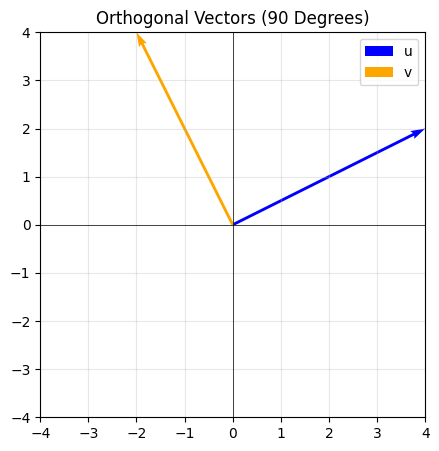

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Define 2 orthogonal vectors in R^2
# Vectors are orthogonal if dot product is 0 (x1 * x2) + (y1 * y2) = 0
u = np.array([4, 2], dtype=float)
v = np.array([-2, 4], dtype=float)

# Check if dot product is 0
dot_product = np.dot(u, v)
print("Dot product of u and v: ", dot_product)

# Create orthonormal vectors (where the length is 1 and both are orthogonal):
u_unit = u / np.linalg.norm(u)
v_unit = v / np.linalg.norm(v)
print("Norm of u_unit: ", u_unit)
print("Dot product of u_unit and v_unit: ", np.dot(u_unit, v_unit))

# Visualizations
plt.figure(figsize=(5, 5))
plt.quiver(0, 0, u[0], u[1], angles='xy', scale_units='xy', scale=1, color='blue', label='u')
plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='orange', label='v')
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.title("Orthogonal Vectors (90 Degrees)")
plt.show()

# 3. Gram-Schmidt Process

Key Concepts (Explained and given python examples):

*   Gram-Schmidt Process:

The Gram-Schmidt Process is an algorithm that takes in non-perpendicular vectors and obtains an orthonormal basis in the same subspace.


*   Example:




In [30]:
# Define matrix A where the columns are 3 linearly independent vectors
A = np.array([[7, 3, 0],
             [5, 10, 2],
             [0, 8, 7]], dtype=float)
A2 = np.array([[7, 3, 0],
             [5, 10, 2],
             [0, 8, 7]], dtype=float)

# Perform Gram-Schmidt using numpy's QR decomposition
# Q contains the orthonormal basis vectors as its columns
Q,R = np.linalg.qr(A)

# A manual gram-schmidt loop that illustrates how the math is done
def simple_gram_schmidt(A2):
    Q1 = np.zeros_like(A2, dtype=float)

    # The outer loop processes each vector column one by one
    for i in range(A2.shape[1]):
        v = A2[:, i]
        # The inner loop subtracts projections onto all previous orthonormal vectors
        for j in range(i):
            v = v - np.dot(Q1[:, j], A2[:, i]) * Q1[:, j]  # Subtract projection

        Q1[:, i] = v / np.linalg.norm(v)   # Normalize to length 1
    return Q1

# Test manual function
Q_manual = simple_gram_schmidt(A)

print("Original Matrix A: ")
print(A)

print("Orthonormal Basis Matrix Q (Result of Gram-Schmidt): ")
print(np.round(Q,4))

print("Orthonormal Basis Matrix Q (Result of manual function): ")
print(np.round(Q_manual,4))

# Now we can verify the gram-schmidt process was succesful.
# We can ensure this by making sure Q^T @ Q equals the identity matrix
QT_MAN = Q_manual.T @ Q_manual
QT_Q = Q.T @ Q
print("Verify that Q^T @ Q equals the identity matrix: ")
print(np.round((QT_Q),4))
print("Also verify our manual loop: " )
print(np.round((QT_MAN),4))
print("Is Q truly orthonormal?", np.allclose(QT_Q, np.eye(3)))



Original Matrix A: 
[[ 7.  3.  0.]
 [ 5. 10.  2.]
 [ 0.  8.  7.]]
Orthonormal Basis Matrix Q (Result of Gram-Schmidt): 
[[-0.8137  0.3629  0.454 ]
 [-0.5812 -0.508  -0.6357]
 [-0.     -0.7812  0.6243]]
Orthonormal Basis Matrix Q (Result of manual function): 
[[ 0.8137 -0.3629  0.454 ]
 [ 0.5812  0.508  -0.6357]
 [ 0.      0.7812  0.6243]]
Verify that Q^T @ Q equals the identity matrix: 
[[ 1.  0. -0.]
 [ 0.  1.  0.]
 [-0.  0.  1.]]
Also verify our manual loop: 
[[ 1. -0.  0.]
 [-0.  1. -0.]
 [ 0. -0.  1.]]
Is Q truly orthonormal? True


Since $Q^TQ$ (Q transposed multiplied by itself) is the identity matrix, the Gram-Schmidt process was succesful and obtained the orthonormal basis in the subspace.

# 4. Eigenvalue and Eigenvectors

Key Concepts (Explained and given python examples):

Context: When you multiply a vector by a matrix A, the vector usually rotates to a new direction.

*   Eigenvectors:

Vectors that don't rotate, staying on the original line and stretching, shrinking, or flipping.

*   Eigenvalues($λ$):

The factor the eigenvector is scaled by.

*   Example:



In [31]:
# Define our afforementioned matrix, A
A = np.array([[4,1],
              [2,3]], dtype=float)

# We can also compute the eigenvalues and eigenvectors using numpy
eigenval, eigenvec = np.linalg.eig(A)

# print everything
print("Matrix A: ")
print(A)
print("\n")
print("Eigenvalues: ")
print(eigenval)
print("\n")
print("Eigenvectors: ")
print(eigenvec)

# Verify (check that A @ v is equal to lambda * v for each pair):
for i in range(len(eigenval)):
    lam = eigenval[i]
    v = eigenvec[:, i]

    left_side = A @ v
    right_side = lam * v
    residual_norm = np.linalg.norm(left_side - right_side)

    print(f"\n--- Verification for Eigenpair {i+1} ---")
    print(f"lambda = {lam:.4f}")
    print(f"v = {np.round(v, 4)}")
    print("A @ v:", np.round(left_side, 4))
    print("lambda * v:", np.round(right_side, 4))
    print("Residual Norm (Error):", np.round(residual_norm, 8))

Matrix A: 
[[4. 1.]
 [2. 3.]]


Eigenvalues: 
[5. 2.]


Eigenvectors: 
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]

--- Verification for Eigenpair 1 ---
lambda = 5.0000
v = [0.7071 0.7071]
A @ v: [3.5355 3.5355]
lambda * v: [3.5355 3.5355]
Residual Norm (Error): 0.0

--- Verification for Eigenpair 2 ---
lambda = 2.0000
v = [-0.4472  0.8944]
A @ v: [-0.8944  1.7889]
lambda * v: [-0.8944  1.7889]
Residual Norm (Error): 0.0


# Checklist


*   Read, checked, and personalized each example. Also extended at least one example. They run without errors.
*   Covered key concepts from the textbook and illustrated them in python.
*   Explanations written in my own words accompany each example.
*   Saved directly from collab to github.
*   Carefully formatted, code is explained in comments, and it follows the given order from the textbook and in the canvas assignments.




